# PCMCI + ParCorr — All Crops, Monthly

Two-phase analysis:

1. **Climate-only** (`climate`, 10 vars) — run once per crop, no RV. Recovers the inter-variable causal structure within climate alone. Climate variables differ by crop growing region (prcp, awnd, tmin, tmax, pdsi are region-specific), so each crop gets its own climate graph.

2. **Per-crop RV analysis** (`climate_rv`, `macro_news_climate_rv`) — run per crop with crop-specific `weekly_rv`. Tests whether climate and macro/news variables Granger-cause each crop's realized volatility.

Preprocessing identical to `eda_preprocessing.ipynb`: interpolate → ffill → Gaussian detrend (15-yr) → anomalize → `pp.trafo2normal`.

## 0. Imports & Configuration

In [1]:
import sys
from pathlib import Path

ROOT = Path('.').resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Configuration ─────────────────────────────────────────────────────────────
CROPS     = ['corn', 'soybean', 'wheat']
FREQUENCY = 'monthly'

CYCLE_LEN    = 12                   # months per year
SMOOTH_WIDTH = 15 * CYCLE_LEN       # 15-year Gaussian detrend window
TAU_MAX      = 3                    # from eda_preprocessing.ipynb analysis

print(f'Crops     : {CROPS}')
print(f'Frequency : {FREQUENCY}')
print(f'tau_max   : {TAU_MAX}')
print(f'cycle_len : {CYCLE_LEN}')

Crops     : ['corn', 'soybean', 'wheat']
Frequency : monthly
tau_max   : 3
cycle_len : 12


## 1. Feature Group Definitions

| Group | Variables | N |
|-------|-----------|---|
| `rv` | `weekly_rv` | 1 |
| `climate` | `prcp`, `awnd`, `tmin`, `tmax`, `co2`, `pdsi`, `EVAP`, `soil_moisture_mean_m3m3`, `cloud_cover_mean_pct`, `humidity_mean_pct` | 10 |
| `macro` | `DJIA_Index`, `WTI_Index`, `Broad_Dollar_index`, `Stock_Uncertainty` | 4 |
| `news` | `frbsf_sentiment`, `epu_index`, `Text_Climate_Anomaly` | 3 |

**Phase 1 — climate-only (run per crop, no RV):**

| Feature Set | Groups | N | Why run separately |
|-------------|--------|---|--------------------|
| `climate` | climate | 10 | Climate causal structure is independent of RV; isolates physical chains before adding the financial target |

**Phase 2 — per-crop RV analysis:**

| Feature Set | Groups | N | Purpose |
|-------------|--------|---|---------|
| `climate_rv` | climate + rv | 11 | Tests climate → RV Granger-causality after conditioning on RV's own past |
| `macro_news_climate_rv` | macro + news + climate + rv | 18 | Full model; tests whether macro/news mediate or suppress climate → RV links |

In [2]:
FEATURE_GROUPS = {
    'rv'     : ['weekly_rv'],
    'climate': ['prcp', 'awnd', 'tmin', 'tmax', 'co2', 'pdsi',
                'EVAP', 'soil_moisture_mean_m3m3', 'cloud_cover_mean_pct', 'humidity_mean_pct',
                'ssta_elino', 'ssta_lanina', 'SOI_index', 'NAO_index'],
    'macro'  : ['DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty'],
    'news'   : ['frbsf_sentiment', 'epu_index', 'Text_Climate_Anomaly'],
}

GROUP_COLORS = {
    'rv': '#e41a1c', 'climate': '#377eb8', 'macro': '#4daf4a', 'news': '#984ea3',
}

FEATURE_SETS = {
    'climate'              : ['climate'],
    'climate_rv'           : ['climate', 'rv'],
    'macro_climate_rv'     : ['macro', 'climate', 'rv'],
    'macro_news_climate_rv': ['macro', 'news', 'climate', 'rv'],
}

def build_cols(groups: list[str]) -> list[str]:
    cols: list[str] = []
    for g in groups:
        cols.extend(FEATURE_GROUPS[g])
    return cols

def group_of(col: str) -> str:
    for g, cols in FEATURE_GROUPS.items():
        if col in cols:
            return g
    return 'other'

for name, groups in FEATURE_SETS.items():
    print(f'{name:30s}: {len(build_cols(groups)):2d} vars')

climate                       : 14 vars
climate_rv                    : 15 vars
macro_climate_rv              : 19 vars
macro_news_climate_rv         : 22 vars


## 2. Preprocessing & PCMCI Helper Functions

Preprocessing pipeline (identical to `eda_preprocessing.ipynb`):

| Step | Method | Why |
|------|--------|-----|
| Impute | Interpolate `pdsi`/`Broad_Dollar_index`, ffill `DJIA_Index` | Fill isolated gaps before detrending |
| Detrend | `pp.smooth(residuals=True, kernel='gaussian', smooth_width=15yr)` | CO₂/DJIA/Broad Dollar have 10–35% secular drift — removes spurious common-driver links |
| Anomalize | Subtract phase mean, divide by phase std | Annual cycles in temp/precip/EVAP inflate cross-group correlations |
| Gaussianise | `pp.trafo2normal` | 15/18 features non-Gaussian (SW p<0.05); ParCorr t-test null requires Gaussian marginals |

In [3]:
import networkx as nx

def load_and_preprocess(crop: str, frequency: str) -> tuple[np.ndarray, list[str], pd.Series]:
    """Load CSV, impute, detrend, anomalize, Gaussianise. Returns (arr_normal, col_names, dates)."""
    path = ROOT / 'data' / frequency / f'{crop}.csv'
    raw  = pd.read_csv(path, parse_dates=['date'])
    df   = raw.sort_values('date').reset_index(drop=True)

    for col in ['pdsi', 'Broad_Dollar_index']:
        if col in df.columns:
            df[col] = df[col].interpolate(method='linear', limit_direction='both')
    for col in ['DJIA_Index']:
        if col in df.columns:
            df[col] = df[col].ffill().bfill()
    df = df.dropna().reset_index(drop=True)

    col_names = [c for c in df.columns if c != 'date']
    arr = df[col_names].values.astype(float)

    cycle_len    = 52 if frequency == 'weekly' else 12
    smooth_width = 15 * cycle_len
    arr_detrended = pp.smooth(arr, smooth_width=smooth_width, kernel='gaussian', residuals=True)

    arr_anom = arr_detrended.copy().astype(float)
    for phase in range(cycle_len):
        idx = slice(phase, None, cycle_len)
        arr_anom[idx] -= arr_detrended[idx].mean(axis=0)
        std = arr_detrended[idx].std(axis=0)
        std[std == 0] = 1.0
        arr_anom[idx] /= std

    arr_normal = pp.trafo2normal(arr_anom)
    return arr_normal, col_names, df['date']


def run_parcorr(
    feature_set_name: str,
    col_names: list[str],
    arr_preprocessed: np.ndarray,
    all_cols: list[str],
    tau_max: int,
    pc_alpha: float = 0.2,
    alpha_level: float = 0.05,
    fdr_method: str = 'fdr_bh',
    max_conds_dim: int | None = None,
    verbosity: int = 0,
) -> dict:
    indices     = [all_cols.index(c) for c in col_names]
    data_subset = arr_preprocessed[:, indices]

    dataframe = pp.DataFrame(
        data_subset,
        var_names=col_names,
        datatime={0: np.arange(len(data_subset))},
    )
    parcorr = ParCorr(significance='analytic')
    pcmci   = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=verbosity)

    results = pcmci.run_pcmci(
        tau_min=1, tau_max=tau_max,
        pc_alpha=pc_alpha, alpha_level=alpha_level,
        fdr_method=fdr_method, max_conds_dim=max_conds_dim,
    )
    q_matrix = pcmci.get_corrected_pvalues(
        p_matrix=results['p_matrix'], tau_max=tau_max, fdr_method=fdr_method,
    )
    graph = pcmci.get_graph_from_pmatrix(
        p_matrix=q_matrix, alpha_level=alpha_level, tau_min=1, tau_max=tau_max,
    )
    results.update({
        'graph': graph, 'q_matrix': q_matrix,
        'pcmci': pcmci, 'col_names': col_names,
        'data_subset': data_subset,
    })
    return results


def log_filtered_links(results: dict, val_threshold: float = 0.25) -> pd.DataFrame:
    """Report links where |val| > val_threshold with their p_val, mci_val, and lag_corr."""
    col_names  = results['col_names']
    p_matrix   = results['p_matrix']
    val_matrix = results['val_matrix']
    data       = results['data_subset']

    rows = []
    for j, cause in enumerate(col_names):
        for i, effect in enumerate(col_names):
            for tau in range(1, val_matrix.shape[2]):
                v = val_matrix[j, i, tau]
                if abs(v) > val_threshold:
                    x, y = data[:, j], data[:, i]
                    lag_corr = np.corrcoef(x[:-tau], y[tau:])[0, 1]
                    rows.append({
                        'cause': cause, 'effect': effect, 'lag': tau,
                        'mci_val':  v,
                        'p_val':    p_matrix[j, i, tau],
                        'lag_corr': lag_corr,
                    })

    df = pd.DataFrame(rows)
    if df.empty:
        print(f'  No links with |val| > {val_threshold}')
    else:
        print(f'\n  ── Filtered links (|val| > {val_threshold}): {len(df)} ──')
        print(df.sort_values('p_val').to_string(index=False, float_format='{:.3f}'.format))
    return df


def plot_causal_graph(results: dict, title: str, tau_max: int, val_threshold: float = 0.25) -> None:
    """Interactive pyvis graph — nodes draggable; edges require significance AND |val| > val_threshold."""
    from pyvis.network import Network
    from IPython.display import display, HTML

    col_names  = results['col_names']
    graph      = results['graph']
    val_matrix = results['val_matrix']
    data       = results['data_subset']
    N = len(col_names)

    edge_meta = []
    for j in range(N):
        for i in range(N):
            for tau in range(1, tau_max + 1):
                if graph[j, i, tau] not in ('', 'o-o') and abs(val_matrix[j, i, tau]) > val_threshold:
                    x, y = data[:, j], data[:, i]
                    lag_corr = np.corrcoef(x[:-tau], y[tau:])[0, 1]
                    edge_meta.append((j, i, tau, val_matrix[j, i, tau], lag_corr))

    if not edge_meta:
        print('  No significant links to plot.')
        return

    active_nodes = {n for j, i, *_ in edge_meta for n in (j, i)}

    net = Network(height='640px', width='100%', directed=True, cdn_resources='in_line')
    net.toggle_physics(True)

    for n in range(N):
        if n not in active_nodes:
            continue
        color = GROUP_COLORS.get(group_of(col_names[n]), '#aaaaaa')
        net.add_node(n, label=col_names[n], color=color, title=col_names[n],
                     size=22, font={'size': 13, 'color': '#111111'})

    for j, i, tau, val, lag_corr in edge_meta:
        lbl = f'τ={tau}  val={val:.2f}  r={lag_corr:.2f}'
        net.add_edge(j, i, label=lbl, title=lbl,
                     font={'size': 10, 'align': 'middle'},
                     smooth={'type': 'curvedCW', 'roundness': 0.2},
                     color='#555555', width=2)

    # Legend as HTML above the graph
    legend_items = ''.join(
        f'<span style="display:inline-block;width:12px;height:12px;border-radius:50%;'
        f'background:{c};margin-right:4px;vertical-align:middle"></span>'
        f'<span style="margin-right:14px;font-size:12px">{g}</span>'
        for g, c in GROUP_COLORS.items()
    )
    header = (
        f'<div style="font-family:sans-serif;padding:6px 2px">'
        f'<p style="font-size:14px;font-weight:bold;margin:2px 0">{title}</p>'
        f'<p style="font-size:11px;color:#666;margin:0 0 4px">'
        f'tau_max={tau_max} | FDR-BH α=0.05 | |val|>{val_threshold} '
        f'| drag nodes to rearrange</p>'
        f'<p style="margin:0 0 4px">{legend_items}</p>'
        f'</div>'
    )
    import uuid as _uuid
    _uid = _uuid.uuid4().hex[:8]
    _html = net.generate_html()
    _html = _html.replace('mynetwork', f'net_{_uid}')
    display(HTML(header + _html))


def plot_results(results: dict, title: str, tau_max: int) -> None:
    log_filtered_links(results, val_threshold=0.25)
    plot_causal_graph(results, title, tau_max, val_threshold=0.25)

    col_names = results['col_names']
    n = len(col_names)
    tp.plot_time_series_graph(
        val_matrix=results['val_matrix'], graph=results['graph'],
        var_names=col_names, link_colorbar_label='MCI',
        figsize=(max(12, n * 0.8), 6),
    )
    plt.suptitle(f'{title} — time-series graph', fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def extract_rv_links(results: dict, alpha: float = 0.05) -> pd.DataFrame:
    col_names = results['col_names']
    if 'weekly_rv' not in col_names:
        return pd.DataFrame()
    rv_idx  = col_names.index('weekly_rv')
    q_mat   = results['q_matrix']
    val_mat = results['val_matrix']
    rows = [
        {'cause': col_names[j], 'lag': tau, 'val': val_mat[j, rv_idx, tau],
         'q_val': q_mat[j, rv_idx, tau]}
        for j in range(len(col_names))
        for tau in range(1, q_mat.shape[2])
        if q_mat[j, rv_idx, tau] < alpha
    ]
    return pd.DataFrame(rows)


print('Helper functions defined.')

Helper functions defined.


## 3. Preprocessed Data Overview

All plots below use data after the full pipeline (impute → detrend → anomalize → Gaussianise).

- **Time series** — all 22 variables for corn (representative crop) after preprocessing
- **Distributions** — marginal histograms vs N(0,1) reference; after `trafo2normal` all columns should approximate the red curve
- **Cross-correlations** — CCF of each variable X at lags 0..`tau_max` against `weekly_rv`, shown for all three crops simultaneously

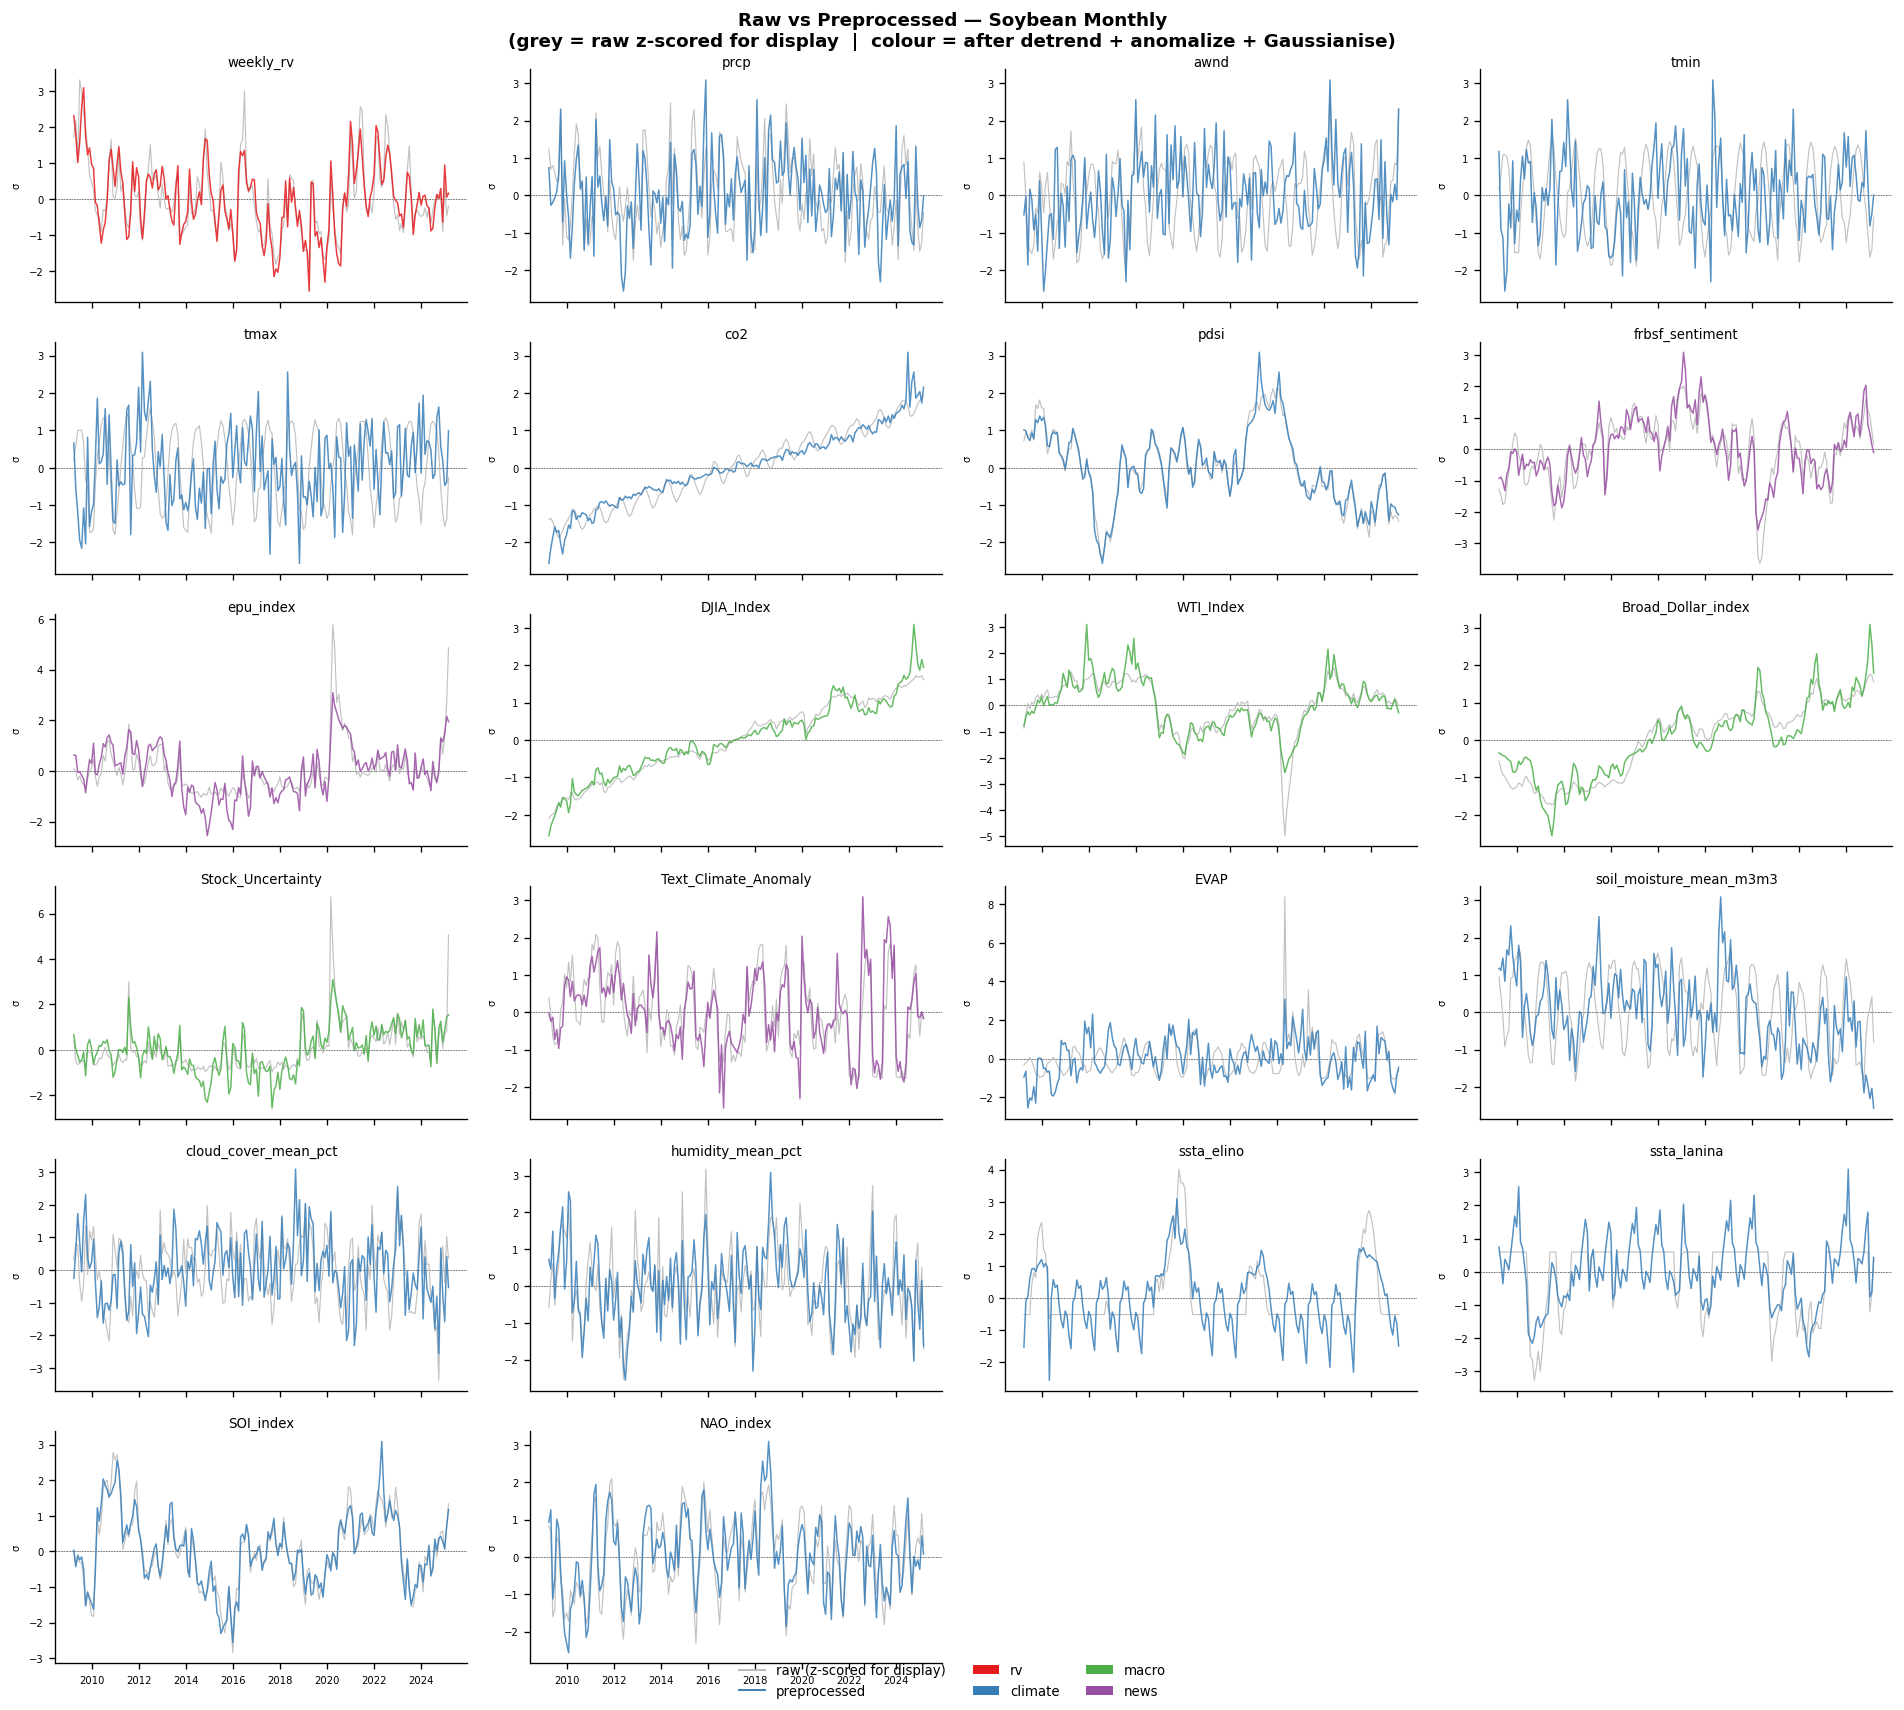

In [4]:
from matplotlib.patches import Patch as _Patch
from matplotlib.lines import Line2D as _Line2D

_raw_df    = pd.read_csv(ROOT / 'data' / FREQUENCY / 'soybean.csv', parse_dates=['date'])
_raw_cols  = [c for c in _raw_df.columns if c != 'date']
_raw_arr   = _raw_df[_raw_cols].values.astype(float)
_raw_dates = _raw_df['date']

_arr0, _cols0, _dates0 = load_and_preprocess('soybean', FREQUENCY)
_N   = len(_cols0)
_ncg = 4
_nrg = (_N + _ncg - 1) // _ncg

fig, axes = plt.subplots(_nrg, _ncg, figsize=(_ncg * 4, _nrg * 2.4), sharex=True)
axes = axes.flatten()
for i, col in enumerate(_cols0):
    ax = axes[i]
    color = GROUP_COLORS.get(group_of(col), '#888')
    if col in _raw_cols:
        _r     = _raw_arr[:, _raw_cols.index(col)].astype(float)
        _r_std = _r.std()
        _r_z   = (_r - _r.mean()) / (_r_std if _r_std > 0 else 1.0)
        ax.plot(_raw_dates, _r_z, lw=0.7, color='#bbbbbb', alpha=0.9, zorder=1)
    ax.plot(_dates0, _arr0[:, i], lw=0.9, color=color, alpha=0.85, zorder=2)
    ax.axhline(0, color='k', lw=0.3, ls='--', zorder=0)
    ax.set_title(col, fontsize=8, pad=2)
    ax.tick_params(labelsize=6)
    ax.set_ylabel('σ', fontsize=6)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
for ax in axes[_N:]:
    ax.set_visible(False)
_leg = [_Line2D([0],[0], color='#bbbbbb', lw=1.2, label='raw (z-scored for display)'),
        _Line2D([0],[0], color='steelblue', lw=1.2, label='preprocessed')]
_leg += [_Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=_leg, loc='lower center', ncol=3, fontsize=8, frameon=False)
fig.suptitle(
    f'Raw vs Preprocessed — Soybean {FREQUENCY.capitalize()}\n'
    '(grey = raw z-scored for display  |  colour = after detrend + anomalize + Gaussianise)',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

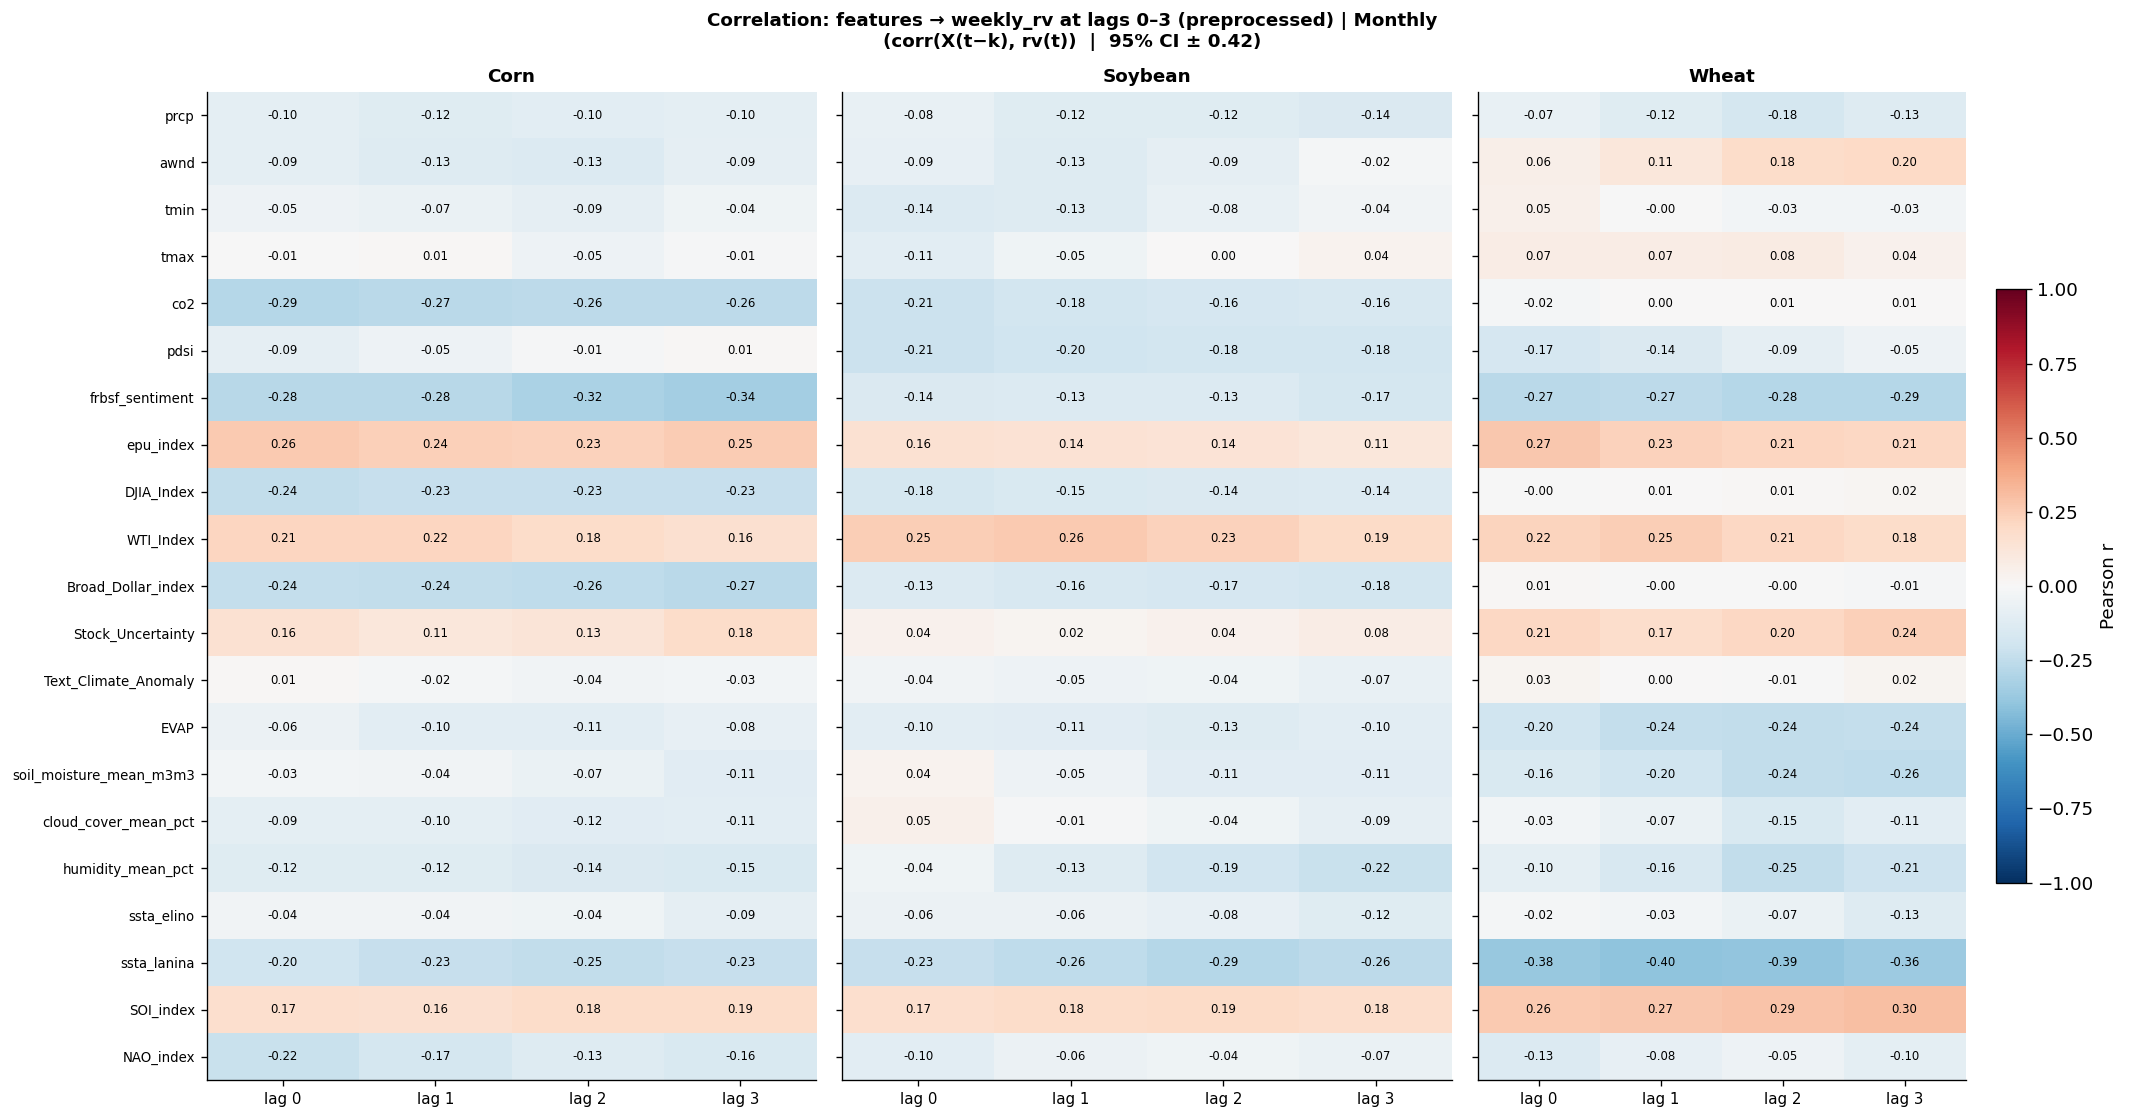

In [5]:
_preproc = {}
for _crop in CROPS:
    _a, _c, _d = load_and_preprocess(_crop, FREQUENCY)
    _preproc[_crop] = (_a, _c, _d)

_LAGS  = [0, 1, 2, 3]
_other = [c for c in _cols0 if c != 'weekly_rv']
_n_oth = len(_other)
_ci    = 1.96 / np.sqrt(_N)

fig, axes = plt.subplots(1, 3, figsize=(18, max(7, _n_oth * 0.38 + 1.5)), sharey=True)

for ax, crop in zip(axes, CROPS):
    arr, cols, _ = _preproc[crop]
    if 'weekly_rv' not in cols:
        continue
    rv = arr[:, cols.index('weekly_rv')]

    corr_mat = np.full((_n_oth, len(_LAGS)), np.nan)
    for li, lag in enumerate(_LAGS):
        for fi, feat in enumerate(_other):
            if feat not in cols:
                continue
            x = arr[:, cols.index(feat)]
            corr_mat[fi, li] = np.corrcoef(x[: len(x) - lag] if lag else x,
                                            rv[lag:] if lag else rv)[0, 1]

    im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(_LAGS)))
    ax.set_xticklabels([f'lag {l}' for l in _LAGS], fontsize=9)
    ax.set_yticks(range(_n_oth))
    ax.set_yticklabels(_other, fontsize=8)

    for fi in range(_n_oth):
        for li in range(len(_LAGS)):
            val = corr_mat[fi, li]
            if not np.isnan(val):
                ax.text(li, fi, f'{val:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if abs(val) > 0.5 else 'black')

    ax.set_title(crop.capitalize(), fontsize=11, fontweight='bold')

plt.colorbar(im, ax=axes[-1], shrink=0.6, label='Pearson r')
fig.suptitle(
    f'Correlation: features → weekly_rv at lags 0–3 (preprocessed) | {FREQUENCY.capitalize()}\n'
    f'(corr(X(t−k), rv(t))  |  95% CI ± {_ci:.2f})',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

## 3. PCMCI + ParCorr — Parameter Suggestions for All Feature Sets

| Feature Set | N | tau_max | pc_alpha | alpha_level | fdr_method | max_conds_dim | Notes |
|-------------|---|---------|----------|-------------|------------|---------------|-------|
| `climate` | 10 | 3 | 0.2 | 0.05 | `fdr_bh` | `None` | Climate-only causal chain |
| `climate_rv` | 11 | 3 | 0.2 | 0.05 | `fdr_bh` | `None` | Tests climate→RV Granger-causality |
| `macro_rv` | 5 | 3 | 0.2 | 0.05 | `fdr_bh` | `None` | Baseline financial model |
| `macro_news_rv` | 8 | 3 | 0.2 | 0.05 | `fdr_bh` | `None` | Adds news sentiment channel |
| `macro_news_climate_rv` | 18 | 3 | 0.2 | 0.05 | `fdr_bh` | `None` | Full model; matches EDA defaults |

**Rationale:**
- **`tau_max=6`**: Monthly RV auto-bivCI decays below 95% significance at lag ~4; lag 3 adds buffer for slower climate signals (matches `eda_preprocessing.ipynb` Section 12).
- **`pc_alpha=0.2`**: Liberal PC skeleton to preserve MCI step power; final FDR at 0.05 controls false links.
- **`max_conds_dim=None`**: Matches EDA sanity-check default. PC step's own pruning controls conditioning-set size; capping would suppress cross-group links.
- **`significance='analytic'`**: Valid after `trafo2normal`; no permutation cost.

## 4. PCMCI Runs — All Feature Sets

Runs all four feature sets for each crop. The `climate` feature set contains no crop-specific
variables and is run once, then reused across crops. Feature sets with `rv` are run per-crop.

| Feature set | Groups | N vars |
|-------------|--------|--------|
| `climate` | climate | 14 |
| `climate_rv` | climate + rv | 15 |
| `macro_climate_rv` | macro + climate + rv | 19 |
| `macro_news_climate_rv` | macro + news + climate + rv | 22 |



######################################################################
  CROP: CORN  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 22)  (2009-04-01 → 2025-03-01)

  ── climate (14 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00009 | val =  0.402

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.569
        (prcp -1): pval = 0.00000 | val =  0.472

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.02792 | val =  0.326

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.520

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable ssta_elino has 1 link(s):
        (sst

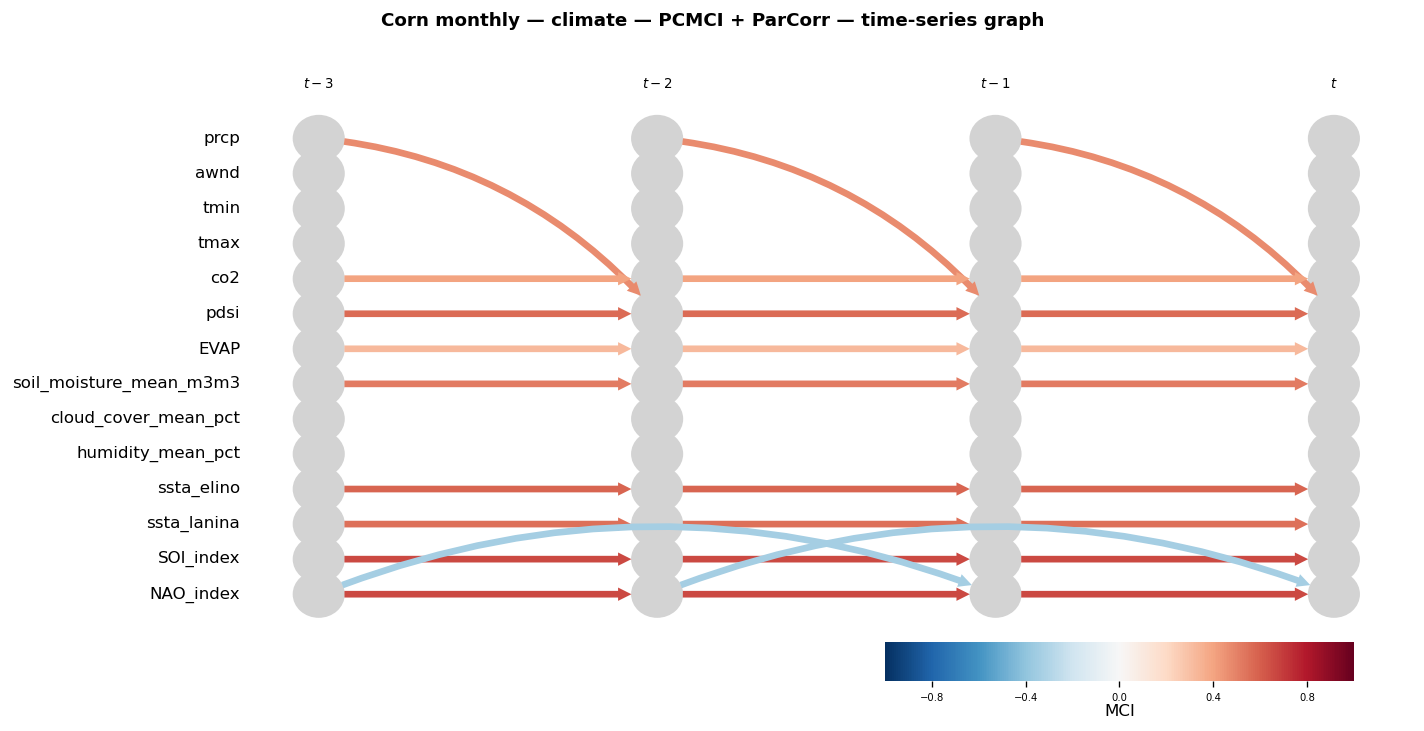


  ── climate_rv (15 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00009 | val =  0.402

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.569
        (prcp -1): pval = 0.00000 | val =  0.472

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.03041 | val =  0.326

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.520

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable ssta_elino has 1 link(s):
        (ssta_elino -1): pval = 0.00000 | val =  0.579

    Variable ssta_lanina has 1 link(s):
        (ssta_lanina -1): pval = 0.00000 | val =  0.550

    Variable SOI_index has 1 link(s):
        (SOI_index -1): pval = 0.00000 | val =  0.

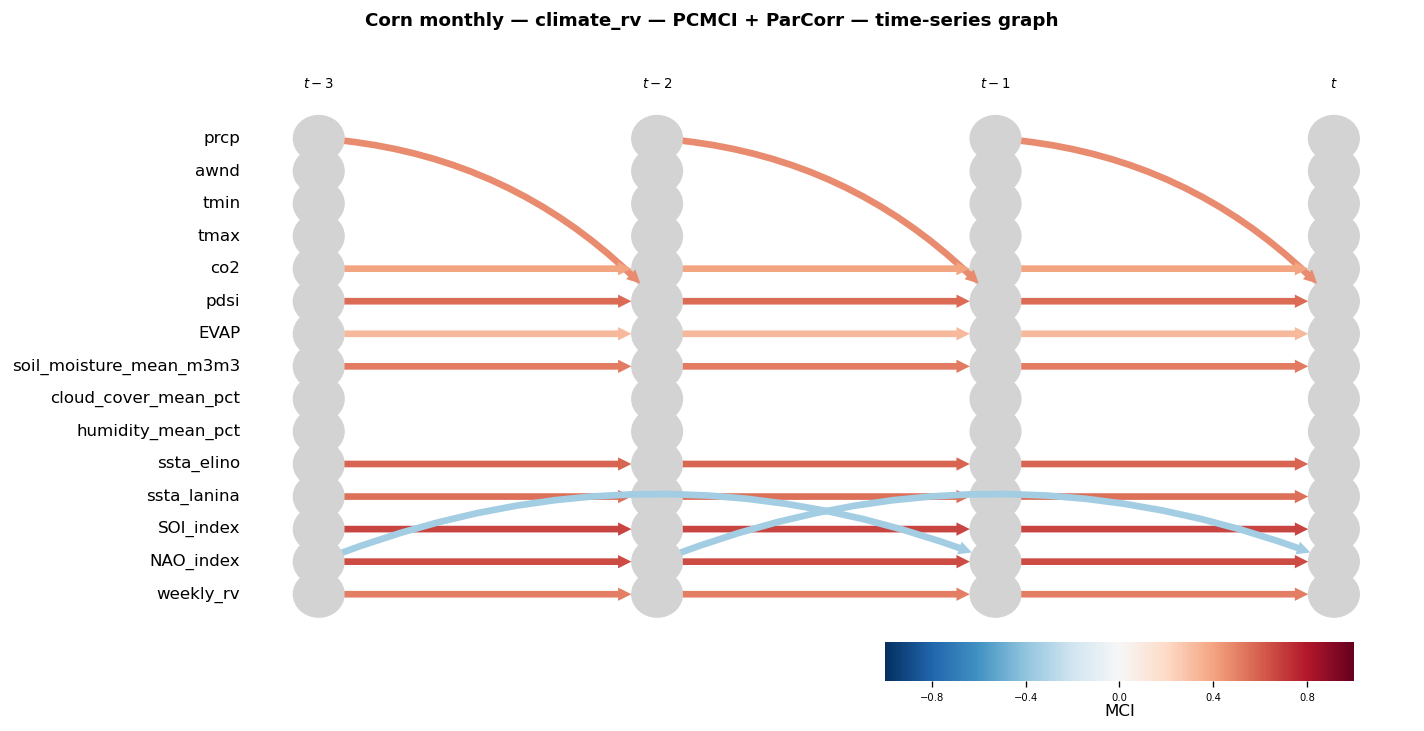


  ── macro_climate_rv (19 vars) ──

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 1 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.656

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.703

    Variable Broad_Dollar_index has 1 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.766

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.505

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00011 | val =  0.402

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.569
        (prcp -1): pval = 0.00000 | val =  0.467

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.525

    Variable

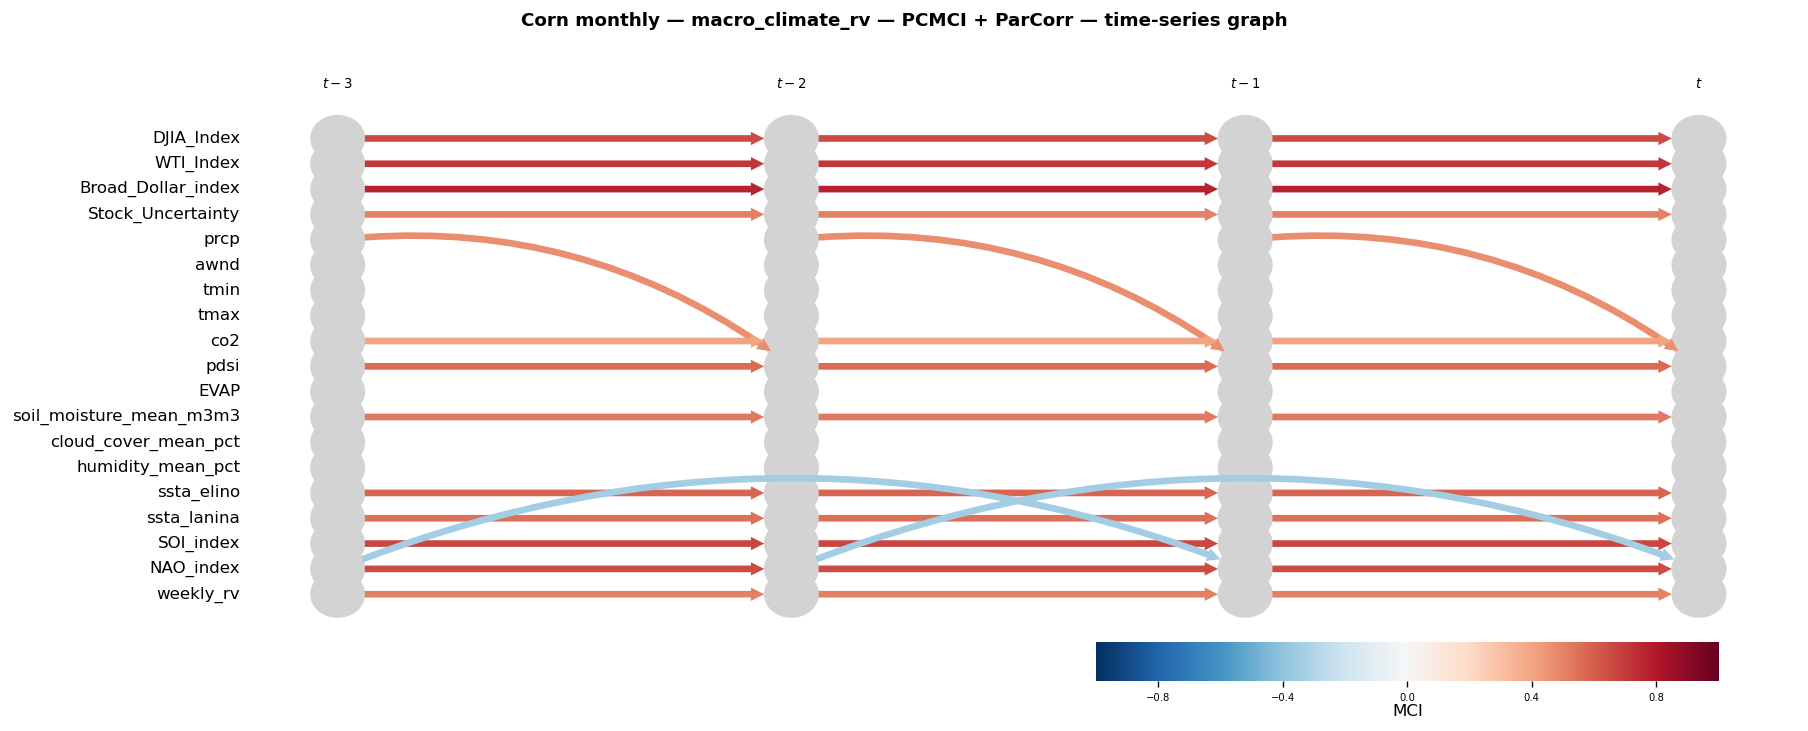


  ── macro_news_climate_rv (22 vars) ──

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 1 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.656

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.705

    Variable Broad_Dollar_index has 1 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.750

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.492

    Variable frbsf_sentiment has 2 link(s):
        (frbsf_sentiment -1): pval = 0.00000 | val =  0.651
        (Stock_Uncertainty -1): pval = 0.01166 | val = -0.350

    Variable epu_index has 1 link(s):
        (epu_index -1): pval = 0.00001 | val =  0.439

    Variable Text_Climate_Anomaly has 1 link(s):
        (Text_Climate_Anomaly -1): pval = 0.00000 | val =  0.480

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):



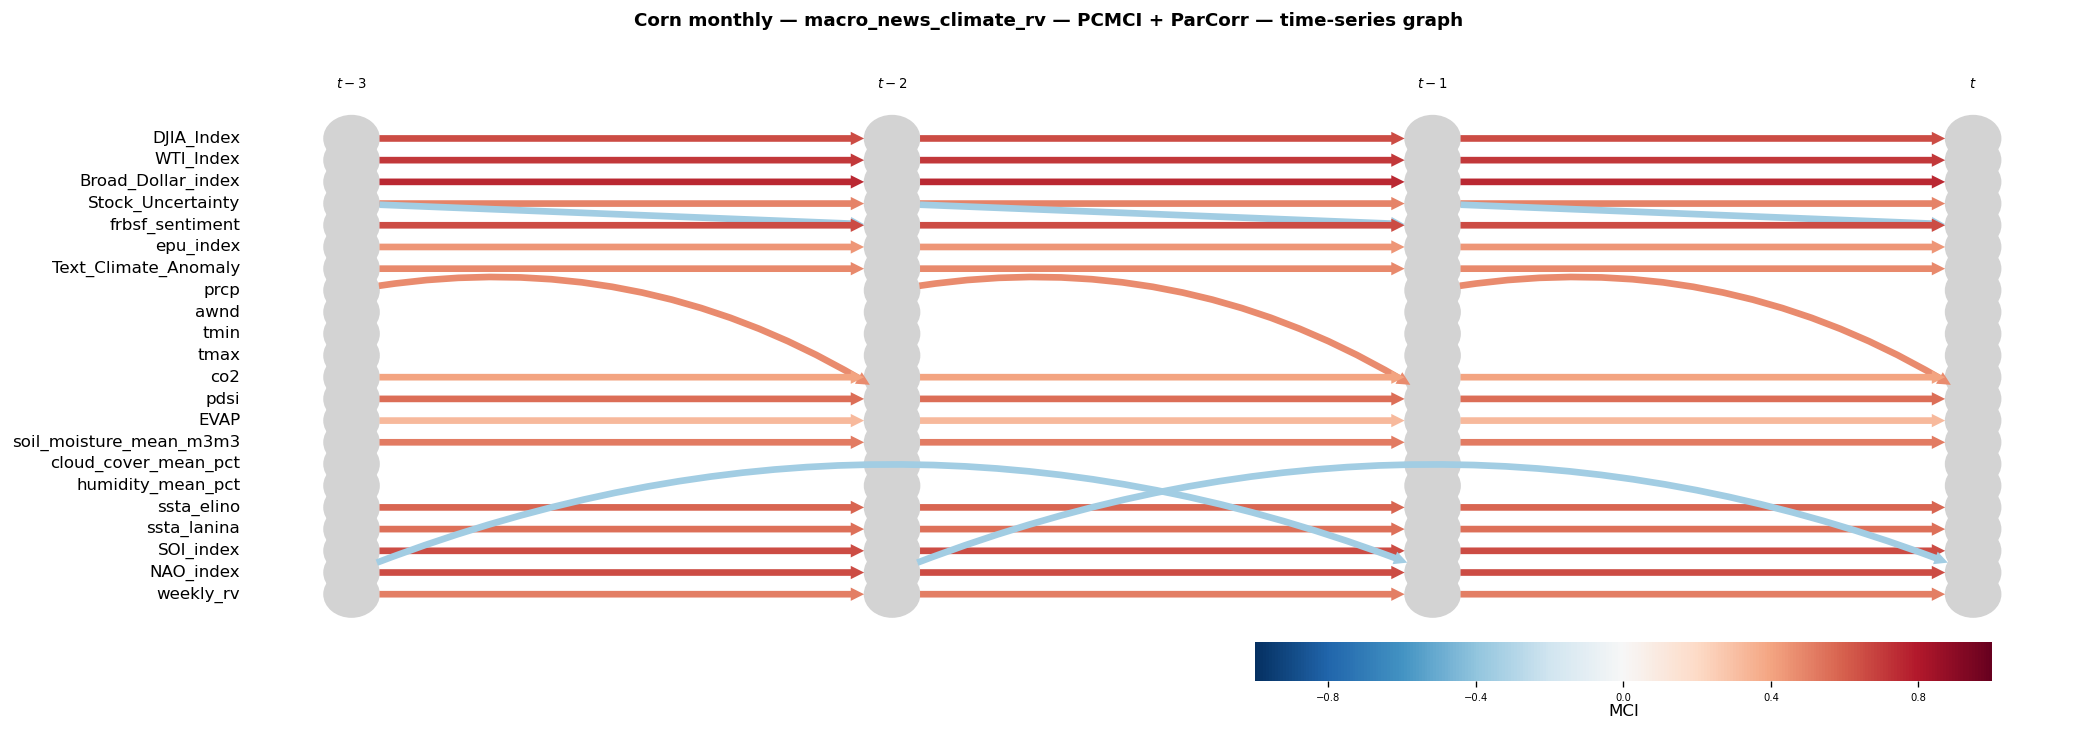


######################################################################
  CROP: SOYBEAN  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 22)  (2009-04-01 → 2025-03-01)
  ── climate (reusing shared result) ──

  ── climate_rv (15 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00001 | val =  0.427

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.561
        (prcp -1): pval = 0.00000 | val =  0.440

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.03267 | val =  0.325

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.520

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    V

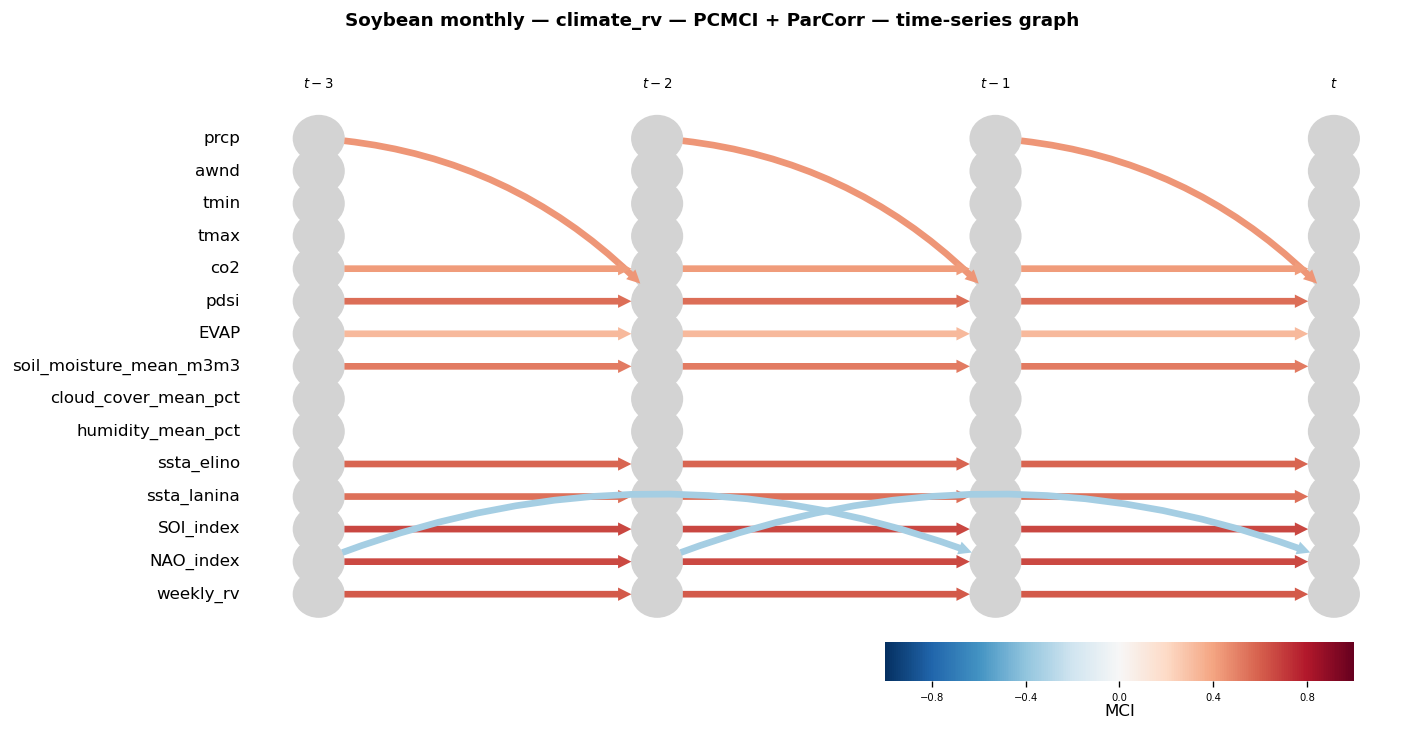


  ── macro_climate_rv (19 vars) ──

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 1 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.656

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.711

    Variable Broad_Dollar_index has 1 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.758

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.505

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00002 | val =  0.427

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.561
        (prcp -1): pval = 0.00001 | val =  0.436

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.456

    Variable

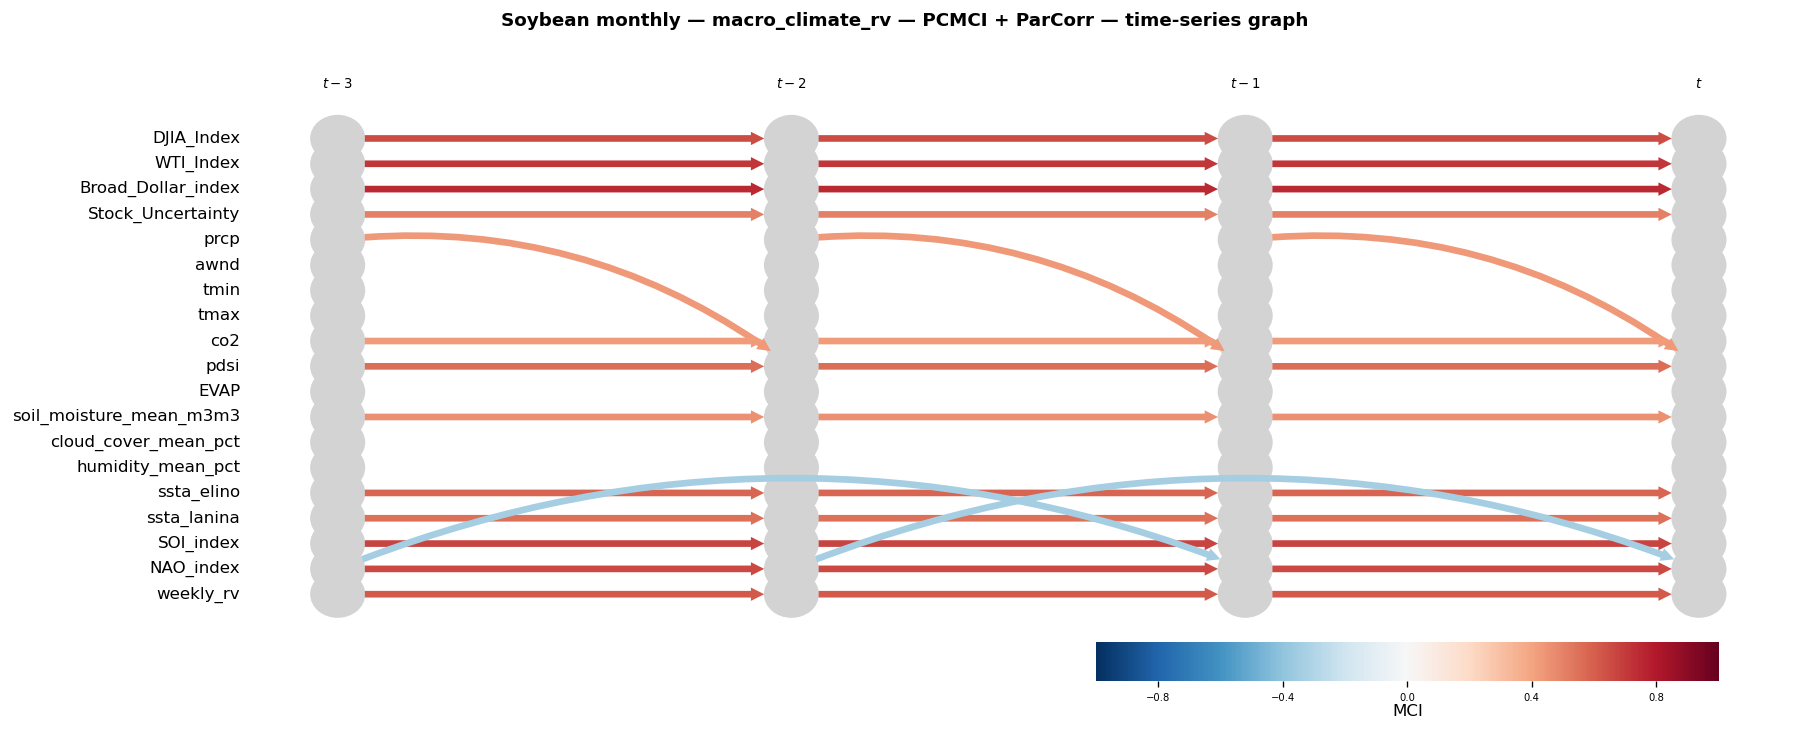


  ── macro_news_climate_rv (22 vars) ──

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 1 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.656

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.709

    Variable Broad_Dollar_index has 1 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.750

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.491

    Variable frbsf_sentiment has 2 link(s):
        (frbsf_sentiment -1): pval = 0.00000 | val =  0.651
        (Stock_Uncertainty -1): pval = 0.01264 | val = -0.350

    Variable epu_index has 1 link(s):
        (epu_index -1): pval = 0.00001 | val =  0.444

    Variable Text_Climate_Anomaly has 1 link(s):
        (Text_Climate_Anomaly -1): pval = 0.00000 | val =  0.480

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):



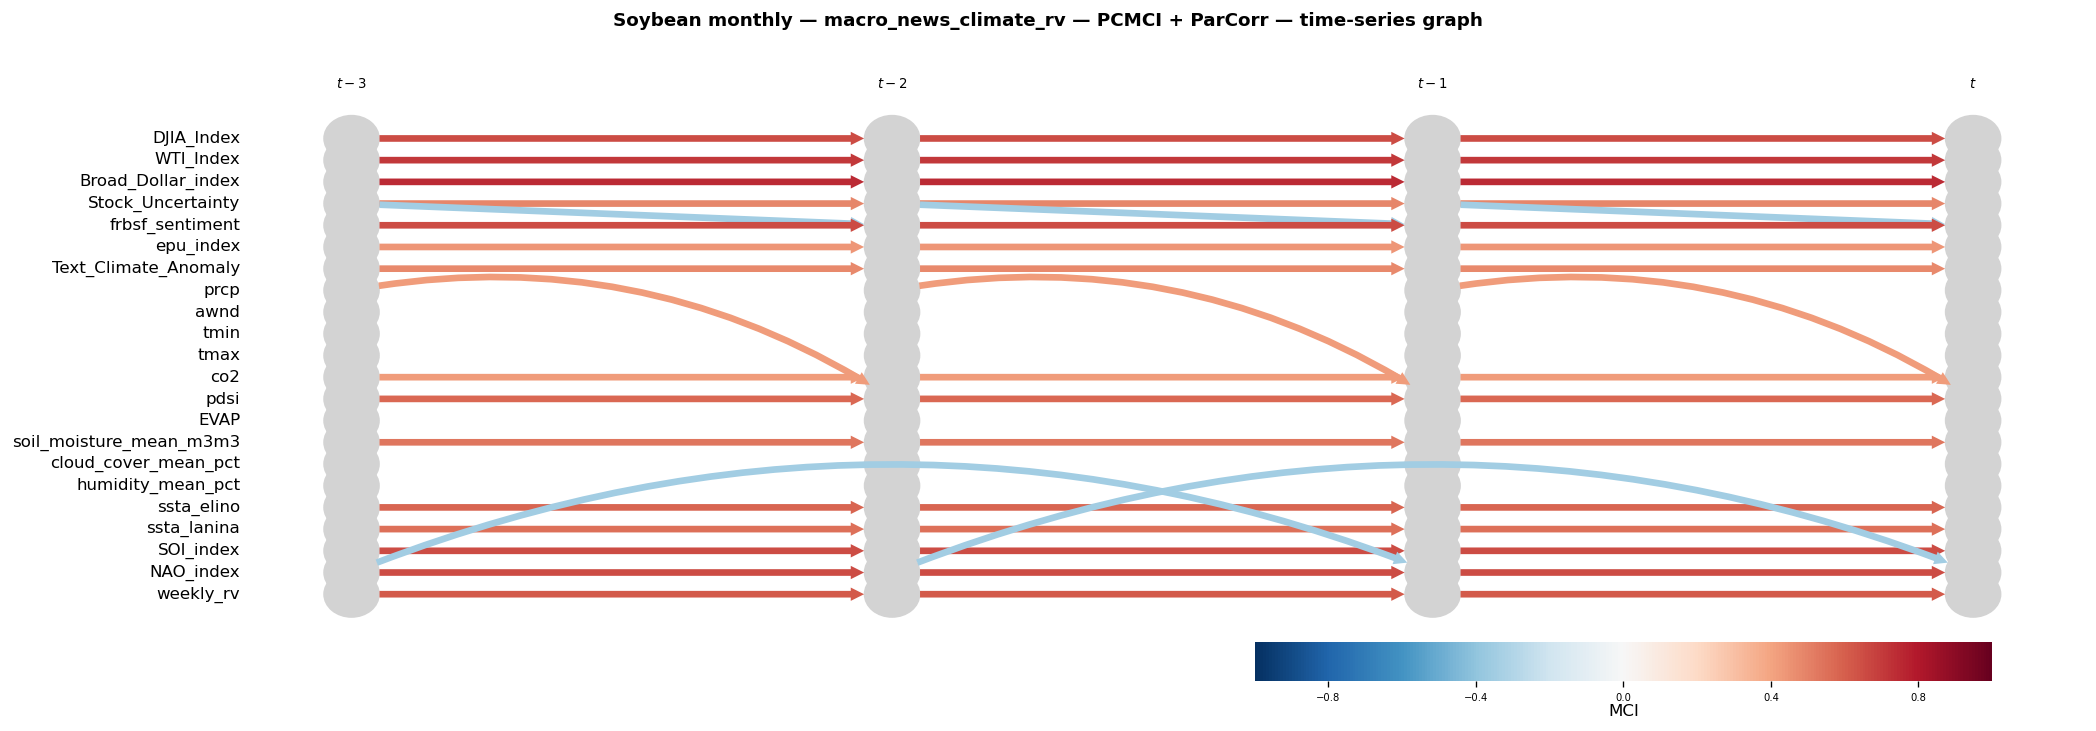


######################################################################
  CROP: WHEAT  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 22)  (2009-04-01 → 2025-03-01)
  ── climate (reusing shared result) ──

  ── climate_rv (15 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00015 | val =  0.402

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00063 | val =  0.389
        (prcp -1): pval = 0.00718 | val =  0.349

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.00691 | val =  0.350

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.520

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Var

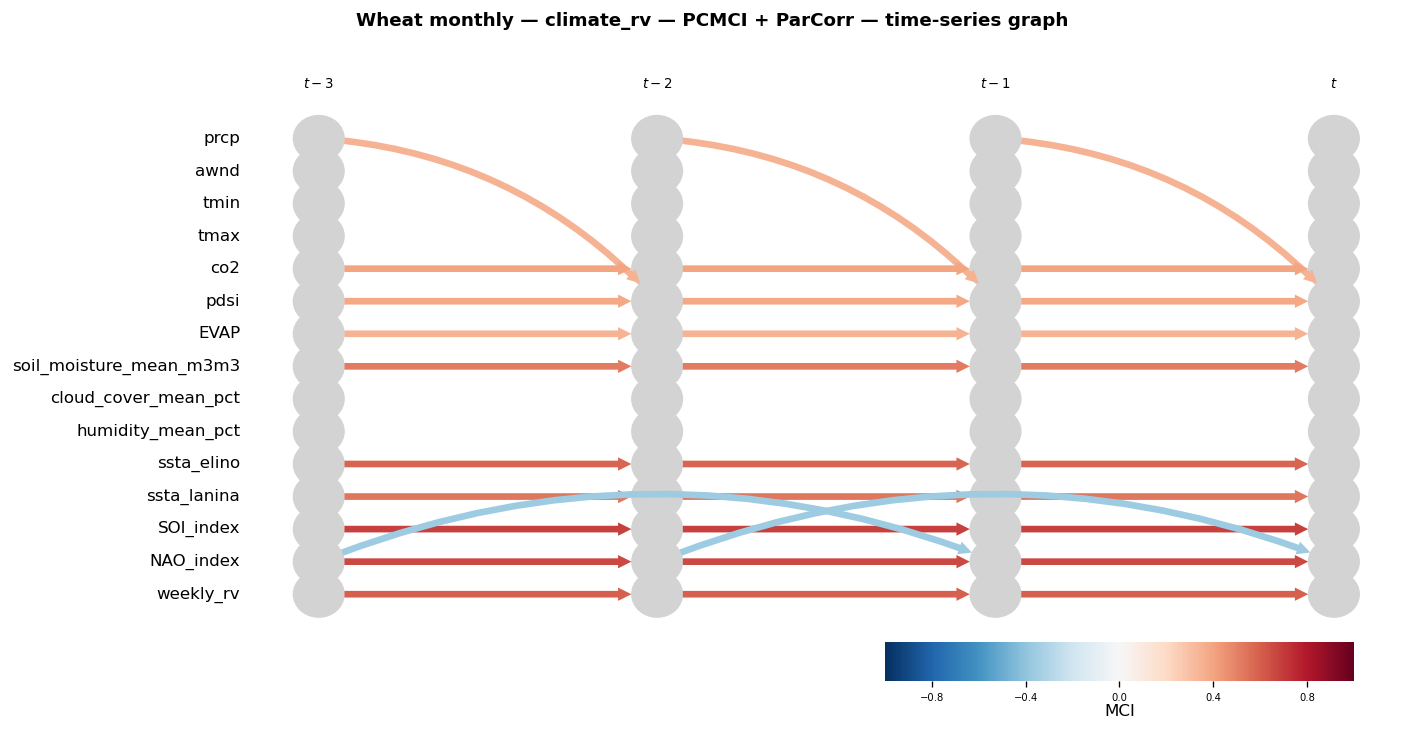


  ── macro_climate_rv (19 vars) ──

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 2 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.656
        (co2 -3): pval = 0.04199 | val =  0.321

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.709

    Variable Broad_Dollar_index has 1 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.750

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.499

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00016 | val =  0.402

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00072 | val =  0.389
        (prcp -1): pval = 0.03385 | val =  0.333

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.02885 | val =  0.335

    Variable soil_moisture_mean_m3m3

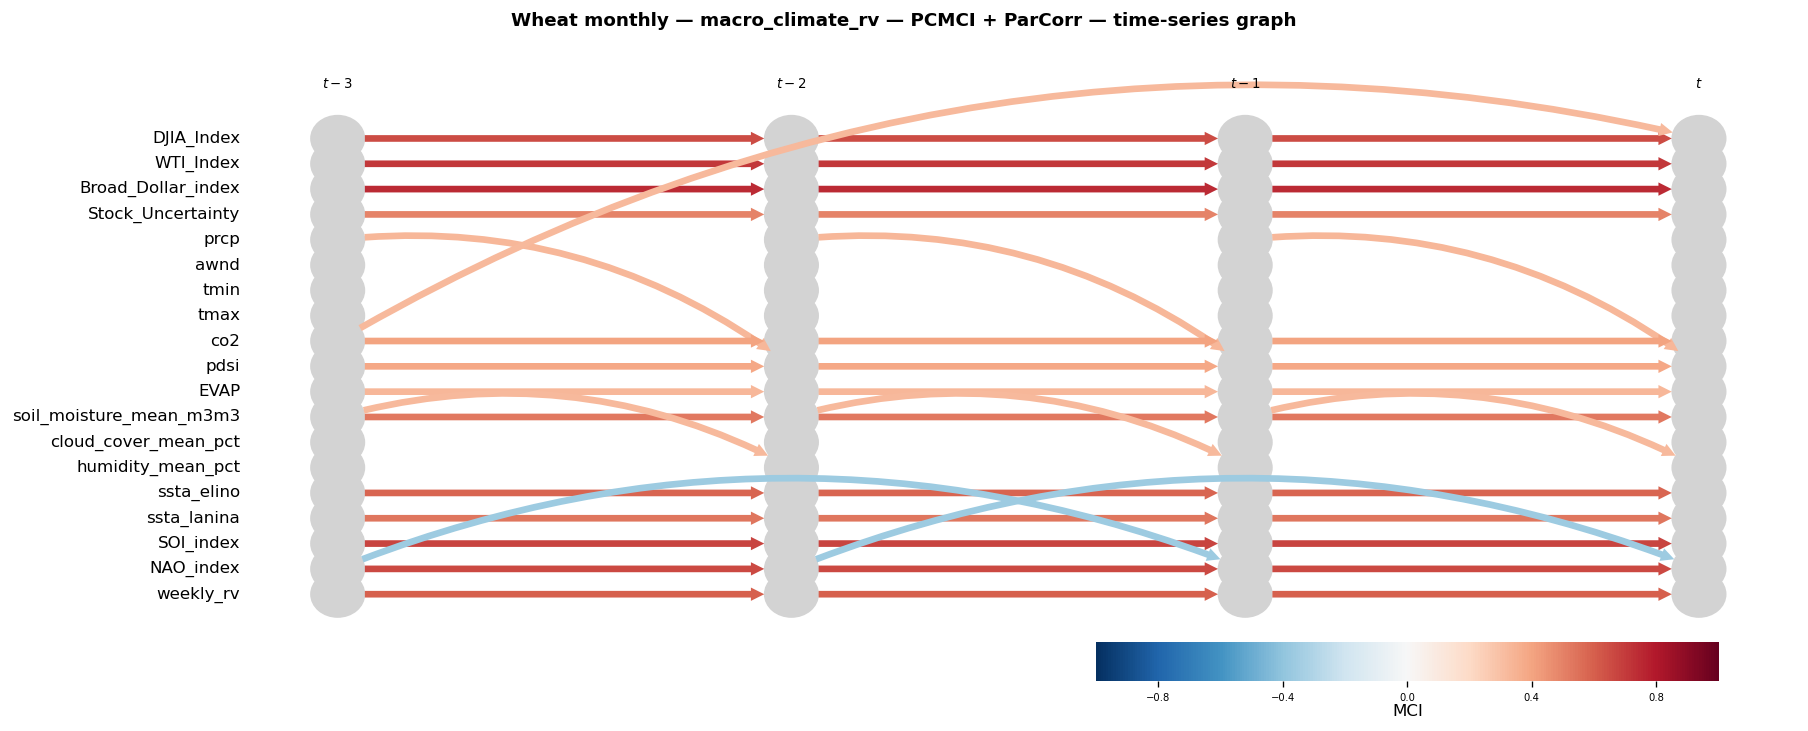


  ── macro_news_climate_rv (22 vars) ──

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 1 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.656

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.711

    Variable Broad_Dollar_index has 1 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.744

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.492

    Variable frbsf_sentiment has 2 link(s):
        (frbsf_sentiment -1): pval = 0.00000 | val =  0.641
        (Stock_Uncertainty -1): pval = 0.04713 | val = -0.331

    Variable epu_index has 1 link(s):
        (epu_index -1): pval = 0.00003 | val =  0.433

    Variable Text_Climate_Anomaly has 1 link(s):
        (Text_Climate_Anomaly -1): pval = 0.00000 | val =  0.499

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):



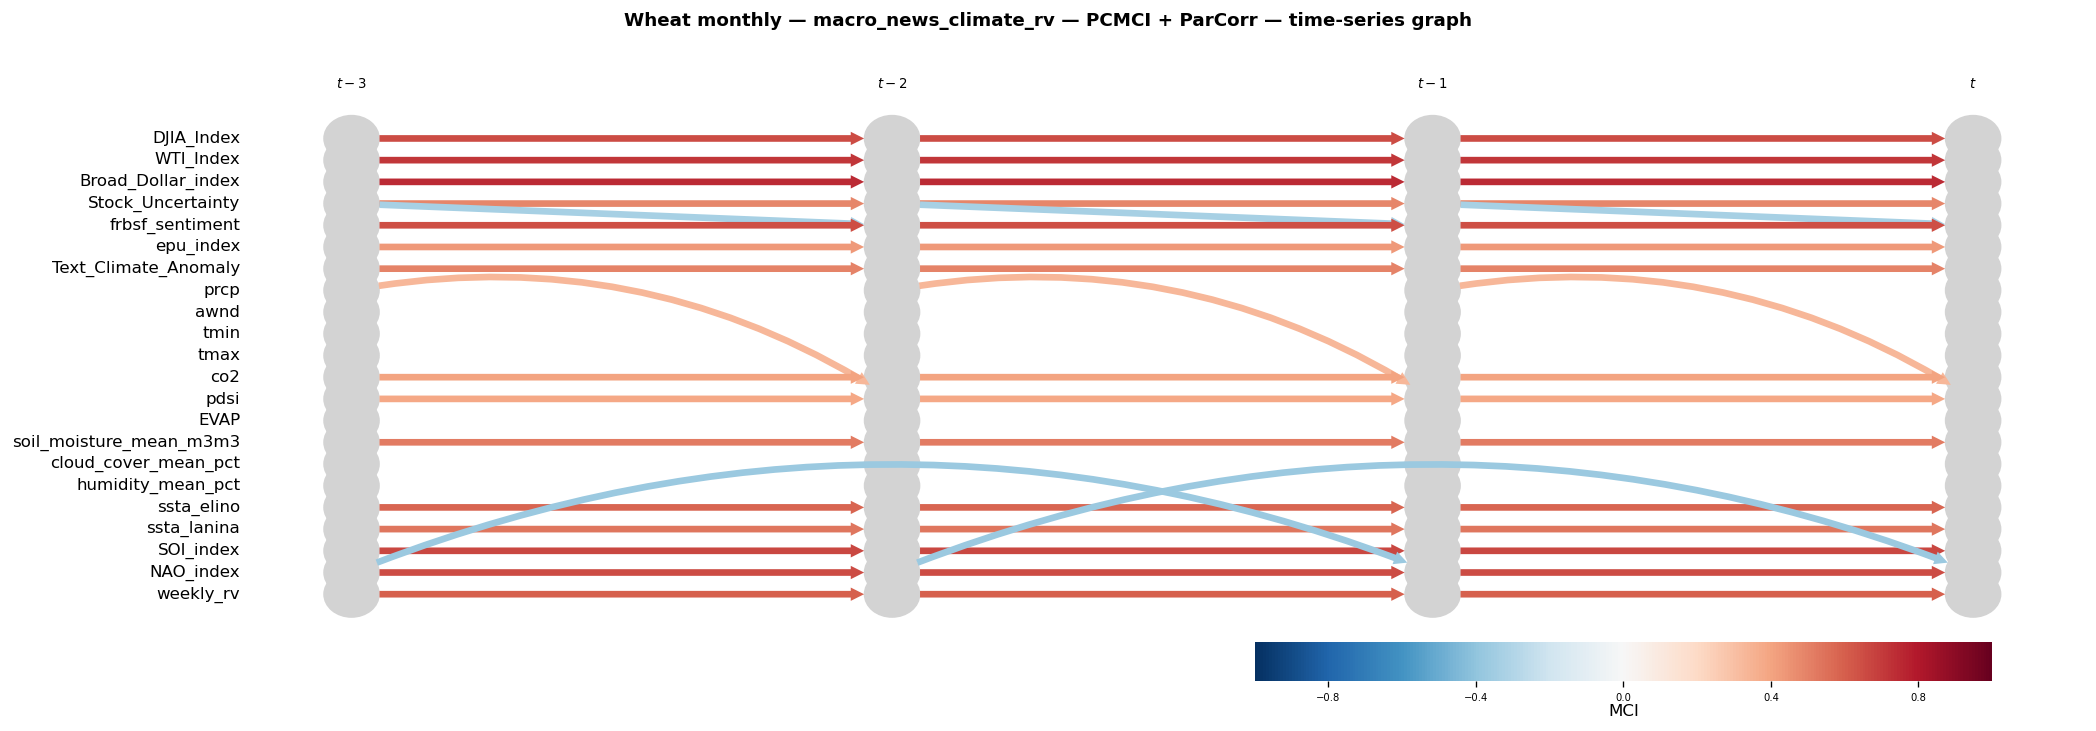


All runs done.


In [6]:
all_results: dict[str, dict] = {}
climate_result: dict | None = None  # climate is crop-agnostic — run once, reuse

for crop in CROPS:
    print(f'\n{"#"*70}')
    print(f'  CROP: {crop.upper()}  |  FREQUENCY: {FREQUENCY.upper()}')
    print(f'{"#"*70}')

    arr_normal, all_cols, dates = load_and_preprocess(crop, FREQUENCY)
    print(f'  Preprocessed: {arr_normal.shape}  '
          f'({dates.min().date()} → {dates.max().date()})')

    all_results[crop] = {}

    for fs_name, groups in FEATURE_SETS.items():
        if fs_name == 'climate' and climate_result is not None:
            all_results[crop][fs_name] = climate_result
            print(f'  ── climate (reusing shared result) ──')
            continue

        col_names = [c for c in build_cols(groups) if c in all_cols]
        print(f'\n  ── {fs_name} ({len(col_names)} vars) ──')

        res = run_parcorr(
            feature_set_name=fs_name,
            col_names=col_names,
            arr_preprocessed=arr_normal,
            all_cols=all_cols,
            tau_max=TAU_MAX,
            pc_alpha=0.2,
            alpha_level=0.05,
            fdr_method='fdr_bh',
            max_conds_dim=None,
            verbosity=0,
        )

        if fs_name == 'climate':
            climate_result = res

        all_results[crop][fs_name] = res

        res['pcmci'].print_significant_links(
            p_matrix=res['q_matrix'],
            val_matrix=res['val_matrix'],
            alpha_level=0.05,
        )
        plot_results(
            res,
            title=f'{crop.capitalize()} {FREQUENCY} — {fs_name} — PCMCI + ParCorr',
            tau_max=TAU_MAX,
        )

print('\nAll runs done.')


In [7]:
for fs_name in ['climate_rv', 'macro_climate_rv', 'macro_news_climate_rv']:
    print(f'\n{"="*65}')
    print(f'  Feature set: {fs_name}')
    print(f'{"="*65}')
    for crop in CROPS:
        links = extract_rv_links(all_results[crop][fs_name])
        print(f'\n  {crop.upper()}:')
        if links.empty:
            print('    No significant links into weekly_rv.')
        else:
            print(links.sort_values('q_val').to_string(index=False,
                  float_format='{:.3f}'.format, col_space=18))



  Feature set: climate_rv

  CORN:
             cause                lag                val              q_val
         weekly_rv                  1              0.515              0.000

  SOYBEAN:
             cause                lag                val              q_val
         weekly_rv                  1              0.616              0.000

  WHEAT:
             cause                lag                val              q_val
         weekly_rv                  1              0.595              0.000

  Feature set: macro_climate_rv

  CORN:
             cause                lag                val              q_val
         weekly_rv                  1              0.504              0.000

  SOYBEAN:
             cause                lag                val              q_val
         weekly_rv                  1              0.616              0.000

  WHEAT:
             cause                lag                val              q_val
         weekly_rv                  1     

## 6. Summary

**Phase 1 — Climate-only (per crop):**  
Recovers the within-climate causal graph for each crop's growing region. Climate variables differ by region (prcp, awnd, tmin, tmax, pdsi), so each crop gets a distinct graph. RV excluded to study physical causal chains in isolation.

**Phase 2 — Per-crop RV analysis:**  
Only `weekly_rv` is crop-specific. Runs `climate_rv` and `macro_news_climate_rv` per crop to test Granger-causality into realized volatility.

**Preprocessing (identical to `eda_preprocessing.ipynb`):**
- Interpolate `pdsi`, `Broad_Dollar_index` | ffill `DJIA_Index`
- `pp.smooth(smooth_width=180, kernel='gaussian', residuals=True)` — 15-yr detrend
- Phase-wise anomalization (`cycle_length=12`)
- `pp.trafo2normal` — rank-based Gaussianisation

**PCMCI + ParCorr config:**
- `tau_min=1`, `tau_max=6`, `pc_alpha=0.2`
- `alpha_level=0.05`, `fdr_method='fdr_bh'`, `max_conds_dim=None`
- `significance='analytic'`

**Next steps:** cross-validate with GPDCtorch (nonlinear additive) and FAISSCMI (nonparametric).